Name : Amardeep Kumar

Roll No : DA25M502

# **Question 8 :** Logistic Regression with L2 Regularization on MNIST

---

In this question, i shall implement binary logistic regression with L2 regularization from scratch using only NumPy.
Use the MNIST dataset and create a binary classification task as follows:
- Class 0: Digit 0
- Class 1: Digit 1

I must:
1. Load the MNIST dataset you may use tensorflow (from tensorflow.keras.datasets
import mnist).
2. Flatten the images and normalize input features.
3. Implement logistic regression with:
- Sigmoid activation function
- Binary cross-entropy loss
- L2 regularization on weights
4. Train the model using batch gradient descent.
Report the following for both training and test sets:
- Loss vs iterations plot
- Confusion matrix
- Accuracy, Precision, Recall, and F1-score
Compare results for different regularization strengths:
λ ∈ {0, 0.01, 0.1, 1.0}

and explain the effect of regularization on overfitting and generalization.

In [ ]:
#import necessary libraries
from google.colab import data_table
data_table.enable_dataframe_formatter()

# from google.colab import data_table
# data_table.disable_dataframe_formatter()

#  load mnist the dataset
from tensorflow.keras.datasets import mnist

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [ ]:
# load minist data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
X_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         54, 227, 253, 252, 239, 233, 252,  57,   6,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10,  60,
        224, 252, 253, 252, 202,  84, 252, 253, 122,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 163, 252,
        252, 252, 253, 252, 252,  96, 189, 253, 167,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 238, 253,
        253, 190, 114, 253, 228,  47,  79, 255, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238, 252, 252,
        179,  12,  75, 121,  21,   0,   0, 253, 243,  50,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  38, 165, 253, 233, 208,
         84,   0,   0,   0,   0,   0,   0, 253, 252, 165,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   7, 178, 252, 240,  71,  19,
         28,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  57, 252, 252,  63,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 198, 253, 190,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 255, 253, 196,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  76, 246, 252, 112,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 148,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 230,  25,   0,   0,   0,
          0,   0,   0,   0,   0,   7, 135, 253, 186,  12,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 223,   0,   0,   0,   0,
          0,   0,   0,   0,   7, 131, 252, 225,  71,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 145,   0,   0,   0,   0,
          0,   0,   0,  48, 165, 252, 173,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  86, 253, 225,   0,   0,   0,   0,
          0,   0, 114, 238, 253, 162,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 249, 146,  48,  29,  85,
        178, 225, 253, 223, 167,  56,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 252, 252, 229, 215, 252,
        252, 252, 196, 130,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  28, 199, 252, 252, 253, 252, 252,
        233, 145,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  25, 128, 252, 253, 252, 141,
         37,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
y_train[1]

np.uint8(0)

## Dataset with 0 and 1

In [ ]:
# as mnist dataset conatin digit 0-9 , but we need to take only digit 0 or 1 for our work so we have to filter 0 and 1 from the dataset

# Filter for digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

#filtered mnist dataset with 0 and 1
X_train_filtered  , y_train_filtered = X_train[train_filter] , y_train[train_filter]
X_test_filtered , y_test_filtered = X_test[test_filter] , y_test[test_filter]


In [ ]:
print("Data Processing Summary ..")
print("="*50)
print("Original MNIST Dataset Summary..")
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print("-"*50)
print("Filtered  MNIST Dataset Summary..")
print(X_train_filtered.shape, y_train_filtered.shape)
print(X_test_filtered.shape, y_test_filtered.shape)

Data Processing Summary ..
Original MNIST Dataset Summary..
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
--------------------------------------------------
Filtered  MNIST Dataset Summary..
(12665, 28, 28) (12665,)
(2115, 28, 28) (2115,)


## Flatten the images and normalize input features.

In [ ]:
# Flatten images (28x28 -> 784)
X_train_filtered = X_train_filtered.reshape(X_train_filtered.shape[0], -1)
X_test_filtered = X_test_filtered.reshape(X_test_filtered.shape[0], -1)
#normalize to [0 to 1]
X_train_filtered = X_train_filtered.astype('float32') / 255
X_test_filtered = X_test_filtered.astype('float32') / 255

In [ ]:
print("Transformed data Summary ..")
print("="*50)
print("Transformed  MNIST Dataset Summary..")
print(X_train_filtered.shape, y_train_filtered.shape)
print(X_test_filtered.shape, y_test_filtered.shape)
print("-"*50)
print("Transformed  MNIST Dataset")
print(X_train_filtered[0])
print(y_train[0])

Transformed data Summary ..
Transformed  MNIST Dataset Summary..
(12665, 784) (12665,)
(2115, 784) (2115,)
--------------------------------------------------
Transformed  MNIST Dataset
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0. 

## Logistic Regression (Using Numpy from Scratch)
**`Logistic Regression Equation:`**

The predicted probability is given by the sigmoid function applied to a linear combination of features:

$$\hat{y} = \sigma(Xw + b)$$
**`Sigmoid Function:`**

The sigmoid function maps any real-valued number to a value between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**`Loss (Binary Cross-Entropy):`**

The Binary Cross-Entropy loss function $L$ for a single sample is:

$$L = -\frac{1}{N} \sum (y \log \hat{y} + (1 - y) \log (1 - \hat{y}))$$

Where:
- $N$ is the number of samples.
- $y$ is the true label (0 or 1).
- $\hat{y}$ is the predicted probability.

**`Gradients:`**

To update the weights $w$ and bias $b$ during gradient descent, we calculate the partial derivatives of the loss function with respect to $w$ and $b$:

**`Gradient of Loss with respect to Weights (dw):`**

$$\frac{\partial L}{\partial w} = \frac{1}{N} X^T (\hat{y} - y)$$

**`Gradient of Loss with respect to Bias (db):`**

$$\frac{\partial L}{\partial b} = \frac{1}{N} \sum (\hat{y} - y)$$

### Defining : Sigmoid + fit + batch Gradient + Binary cross-entropy loss + L2 regularization

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=100,lambda_reg=0.0):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.lambda_reg = lambda_reg
        self.losses = []

    #sigmoid method
    def sigmoid(self,z):
        y_predicted_probability = 1/(1+np.exp(-z))
        return y_predicted_probability

   #computes the Binary Cross-Entropy
    def binary_cross_entropy_loss(self,X,y):
        """
        - True labels y ∈ {0,1}
        - Predicted probabilities y_hat ∈ (0,1) Performs clipping to avoid log(0).
        """
        n_samples = X.shape[0]
        y_predicted_probability = self.sigmoid(np.dot(X,self.w) + self.b)
        epsilon = 1e-15  # A very small number to prevent log(0)
        y_hat = np.clip(y_predicted_probability, epsilon, 1 - epsilon)
        # Use y_hat for BCE calculation to avoid log(0)
        bce_loss =  -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

        #  L2 regularization (only on weights, not bias)
        l2_penalty = (self.lambda_reg / (2 * n_samples)) * np.sum(self.w ** 2)
        return bce_loss + l2_penalty

    #training module
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        y = np.array(y)
        for _ in range(self.num_iterations):
            #pridcting the probability forward pass
            z = np.dot(X,self.w) + self.b
            y_predicted_probability = self.sigmoid(z)

            #calculating graident and this is batch gradient
            dw = (1/n_samples)*np.dot(X.T,(y_predicted_probability -y)) + (self.lambda_reg/n_samples) * self.w
            db = (1/n_samples)*np.sum((y_predicted_probability -y))

            #updating gradient
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            if _ % 10 == 0:
                loss = self.binary_cross_entropy_loss(X, y)
                self.losses.append(loss)

    #prediction module
    def predict(self,X):
        z = np.dot(X,self.w) + self.b
        y_predicted_probability = self.sigmoid(z)
        return (y_predicted_probability >= 0.5).astype(int)

### Confusion Matrix + Accuracy + Precision + Recall + F1-Score

In [ ]:
lembda_l2 =  [0, 0.01, 0.1, 1.0]
iteration_loss = {}
for lambda_reg in lembda_l2:
    # Training
    logistic_regression_model = LogisticRegression(learning_rate=0.1, num_iterations=1000,lambda_reg= lambda_reg )
    logistic_regression_model.fit(X_train_filtered, y_train_filtered)

    #prediction
    train_preds = logistic_regression_model.predict(X_train_filtered)
    test_preds = logistic_regression_model.predict(X_test_filtered)
    iteration_loss[lambda_reg] = logistic_regression_model.losses

    #calculating confusion matrix module
    def confusion_matrix(y_true, y_pred):
        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        return TP, TN, FP, FN

    # Accuracy + Precision + Recall + F1-Score module
    def metrics(y_true, y_pred):
        TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
        accuracy = (TP + TN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP + 1e-9)
        recall = TP / (TP + FN + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        return accuracy, precision, recall, f1

    train_metrics = metrics(y_train_filtered, train_preds)
    test_metrics = metrics(y_test_filtered, test_preds)
    print(f"model performance on regulartion {lambda_reg}:")
    print("="*50)
    print("Training Metrics ")
    print("-"*50)
    print("Accuracy %:", train_metrics[0]*100)
    print("Precision :", train_metrics[1])
    print("Recall :", train_metrics[2])
    print("F1-Score :", train_metrics[3])
    print("\nTesting Metrics ")
    print("-"*50)
    print("Accuracy %:", test_metrics[0]*100)
    print("Precision:", test_metrics[1])
    print("Recall:", test_metrics[2])
    print("F1-Score:", test_metrics[3])
    print()

model performance on regulartion 0:
Training Metrics 
--------------------------------------------------
Accuracy %: 99.8499802605606
Precision : 0.9988128802491468
Recall : 0.9983684366655297
F1-Score : 0.9985906085051183

Testing Metrics 
--------------------------------------------------
Accuracy %: 99.95271867612293
Precision: 0.9991197183089796
Recall: 0.9999999999991189
F1-Score: 0.9995596648447824

model performance on regulartion 0.01:
Training Metrics 
--------------------------------------------------
Accuracy %: 99.8499802605606
Precision : 0.9988128802491468
Recall : 0.9983684366655297
F1-Score : 0.9985906085051183

Testing Metrics 
--------------------------------------------------
Accuracy %: 99.95271867612293
Precision: 0.9991197183089796
Recall: 0.9999999999991189
F1-Score: 0.9995596648447824

model performance on regulartion 0.1:
Training Metrics 
--------------------------------------------------
Accuracy %: 99.8499802605606
Precision : 0.9988128802491468
Recall : 0.9

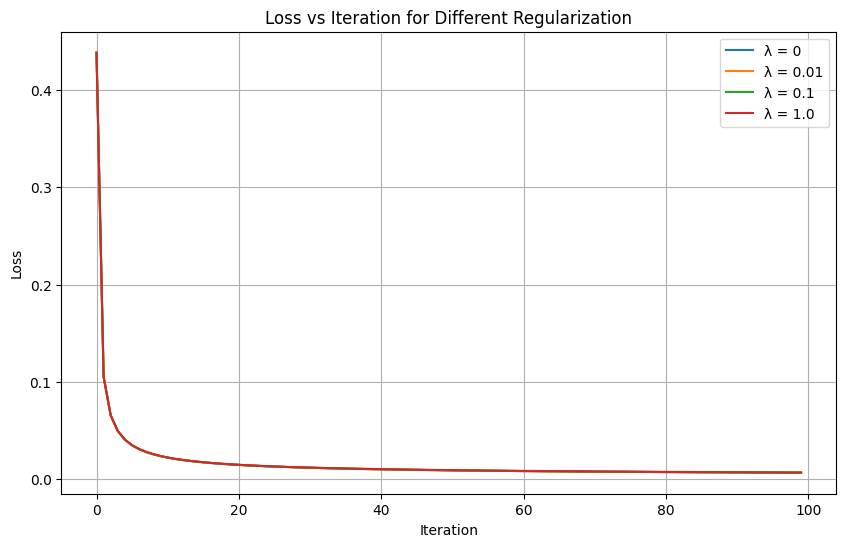

In [ ]:
plt.figure(figsize=(10, 6))
for lambda_reg, losses in iteration_loss.items():
    plt.plot(losses, label=f'λ = {lambda_reg}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration for Different Regularization')
plt.grid(True)
plt.legend()
plt.show()

## Obserbations
- Digits '0' and '1' are inherently very distinct from each other.
- Because the classes are so separable,  logistic regression model is likely achieving near-perfect accuracy.
- If the weights are already relatively small because the problem is easy, then adding a small L2 penalty (like λ = 0.01, 0.1, or even 1.0) might not significantly change their values or the resulting decision boundary.
- The evaluation metrics (accuracy, precision, recall, F1-score) are based on the final binary predictions (0 or 1). If the model's predicted probabilities are already very close to 0 for one class and very close to 1 for the other, slight modifications to these probabilities due to regularization won't cause them to cross the 0.5 decision threshold, resulting in the same binary classifications and thus the same metrics.